## Deliverable 3

Collin Brueggeman

## Problem Statement

Stroke is one of the leading causes of death and disability worldwide. Early prediction of stroke risk can lead to preventive healthcare interventions and reduce healthcare costs. Existing research shows that machine learning models can effectively identify high-risk individuals using health and lifestyle indicators.

The objective of this project is to use predictive analytics to develop a model that predicts the likelihood of stroke occurrence based on patient health attributes. This application of predictive analytics has practical significance for healthcare providers seeking to provide preventive care resources more effectively and can also help individuals make better health decisions.

My problem statement is supported by this systematic review F. Asadi, M. Rahimi, A. H. Daeechini, and A. Paghe, “The most efficient machine learning algorithms in stroke prediction: A systematic review,” Health Science Reports, vol. 7, no. 10, Oct. 2024, doi: https://doi.org/10.1002/hsr2.70062. as it highligts stroke being a major issue and that machine learning/predictive analytics is a growing method of early risk predictions. 

The objective of my project is supported by E. Alanazi, A. Abdou, and J. Luo, “Predicting risk of stroke from lab tests using machine learning algorithms (Preprint),” JMIR Formative Research, Aug. 2020, doi: https://doi.org/10.2196/23440. which details models built on health atributes to predict stroke risk which validates my approach.

This modeling goal is relevant towards both advancing the research filed relating to using predictive analytics in the healthcare field and helping industry by providing insight and advancements in tools to save consumers and businesses/service providers money while maintaining confidence in their abilities. My modeling choices are supported by the systematic review mentioned above where 58 studies were reviewed for what models were used and the results from them.

## Modeling Approaches

In [66]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import graphviz
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Import cleaned dataset into pandas dataframe
heart_data = pd.read_csv('healthcare-dataset-stroke-data_cleaned.csv')

In [67]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      5110 non-null   int64  
 1   gender                          5110 non-null   int64  
 2   age                             5110 non-null   float64
 3   hypertension                    5110 non-null   int64  
 4   heart_disease                   5110 non-null   int64  
 5   ever_married                    5110 non-null   int64  
 6   Residence_type                  5110 non-null   int64  
 7   avg_glucose_level               5110 non-null   float64
 8   bmi                             5110 non-null   float64
 9   stroke                          5110 non-null   int64  
 10  work_type_Never_worked          5110 non-null   bool   
 11  work_type_Private               5110 non-null   bool   
 12  work_type_Self-employed         51

In [68]:
# Set predictors and outcome
predictors = ['avg_glucose_level', 'age', 'bmi', 'gender', 'hypertension', 'heart_disease', 'ever_married', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']
outcome = 'stroke'

X = heart_data[predictors]
y = heart_data[outcome]

In [70]:
# Use SMOTE to remedy class imbalance of outcome 'stroke'
oversample = SMOTE()
X,y = oversample.fit_resample(X,y)

In [71]:
# Split the dataset
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
# Scale the data
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_valid = sc.transform(X_valid)

### Logistic Regression Implementation

In [113]:
# Logistic Regression
# Initialize the model and fit
LogReg = LogisticRegression()
LogReg.fit(X_train, y_train)

# Predict
y_pred_LogReg = LogReg.predict(X_valid)

### SVM Implementation

In [137]:
# Initialize and fit a SVM Model with default hyperparameters
svm = SVC(probability=True) 
svm.fit(X_train, y_train)

# Predict
y_pred_SVM = svm.predict(X_valid)

### Decision Tree Implementation

In [ ]:
# Initialize and fit a decision tree classifier with default hyperparameters called clfDT
clfDT = DecisionTreeClassifier()
clfDT.fit(X_train, y_train)

# Predict
y_pred_clfDT = clfDT.predict(X_valid)

#### Model Justifications and Explanation

Logistic Regression:
- Seen as a strong baseline model for medical classification problems.
- Provides interpretable coefficients that are valuable in the healthcare field for identifying patient attributes that influence conditions.
- Assumptions:
    - Features have a linear relationship with the log-odds of the outcome.
    - Predictor features are not highly multicollinear.
    - Data points are independent.
- Justification:
    - Logistic Regression is suitable for my problem because it is interpretable and performs well when the relationship is roughly linear which commonly happens in medical datasets. Lastly, many of the studies I looked at from the systematic review found in the problem statement use Logistic Regression as a baseline model in their studies.

Support Vector Machine (SVM)
- Kernel functions allow SVM to capture complex decision boundaries around stroke and non-stroke cases.
- Assumptions:
    - The dataset is seperable in some feature space.
    - Patterns can be captured by maximizing the margin between classes.
- Justification:
    - SVM creates robust boundaries and has been seen to be less sensitive to class imbalance when using correct hyperparameters. Many of the studies I looked at had SVM as one of the best performing models which supports its use in this problem.

Decision Tree
- Decision Trees are known for being interpretable and can reveal clear rule-based pathways that even non-technical people such as doctors can understand.
Assumptions:
    - Decision boundaries will be able to be expressed as hierarchical if-then rules.
    - Enough data is present to prevent overfitting.
- Justification:
    - Decision Trees are perfect for this use case because they are able to model complex relationships and have a high degree of interpretability which is important in a life-or-death situation that the helthcare filed often is. Literature also supports the use of Decision Trees as they were among the most commonly tested in the studies I read.

## Evaluation Metrics

### Logistic Regression Evaluation

In [125]:
# Calculate the accuracy score
accuracy_LogReg = accuracy_score(y_valid, y_pred_LogReg)

# Calculate the precision
precision_LogReg = precision_score(y_valid, y_pred_LogReg)

# Calculate the recall
recall_LogReg = recall_score(y_valid, y_pred_LogReg)

# Calculate the F1 Score
f1_LogReg = f1_score(y_valid, y_pred_LogReg)

print("Logistic Regression Metrics")
print(f"Accuracy: {accuracy_LogReg:.3f}")
print(f"Precision: {precision_LogReg:.3f}")
print(f"Recall: {recall_LogReg:.3f}")
print(f"F1 Score: {f1_LogReg:.3f}")


Logistic Regression Metrics
Accuracy: 0.855
Precision: 0.835
Recall: 0.885
F1 Score: 0.859


### SVM Evaluation

In [118]:
# Calculate the accuracy score
accuracy_SVM = accuracy_score(y_valid, y_pred_SVM)

# Calculate the precision
precision_SVM = precision_score(y_valid, y_pred_SVM)

# Calculate the recall
recall_SVM = recall_score(y_valid, y_pred_SVM)

# Calculate the F1 Score
f1_SVM = f1_score(y_valid, y_pred_SVM)

print("SVM Metrics")
print(f"Accuracy: {accuracy_SVM:.3f}")
print(f"Precision: {precision_SVM:.3f}")
print(f"Recall: {recall_SVM:.3f}")
print(f"F1 Score: {f1_SVM:.3f}")



SVM Metrics
Accuracy: 0.871
Precision: 0.855
Recall: 0.893
F1 Score: 0.873


### Decision Tree Evaluation

In [117]:
# Calculate the accuracy score
accuracy_clfDT = accuracy_score(y_valid, y_pred_clfDT)

# Calculate the precision
precision_clfDT = precision_score(y_valid, y_pred_clfDT)

# Calculate the recall
recall_clfDT = recall_score(y_valid, y_pred_clfDT)

# Calculate the F1 Score
f1_clfDT = f1_score(y_valid, y_pred_clfDT)

print("\nDecision Tree Metrics")
print(f"Accuracy: {accuracy_clfDT:.3f}")
print(f"Precision: {precision_clfDT:.3f}")
print(f"Recall: {recall_clfDT:.3f}")
print(f"F1 Score: {f1_clfDT:.3f}")


Decision Tree Metrics
Accuracy: 0.910
Precision: 0.903
Recall: 0.918
F1 Score: 0.910


### Visualizations

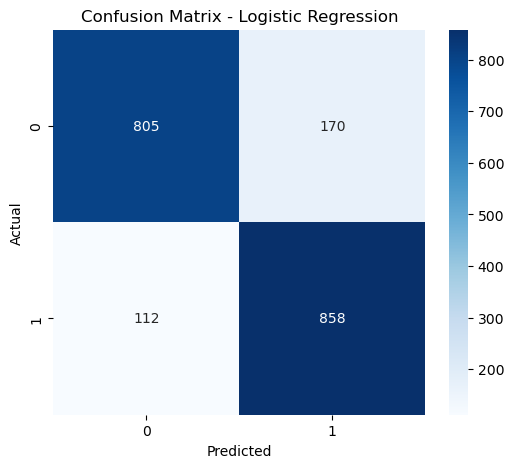

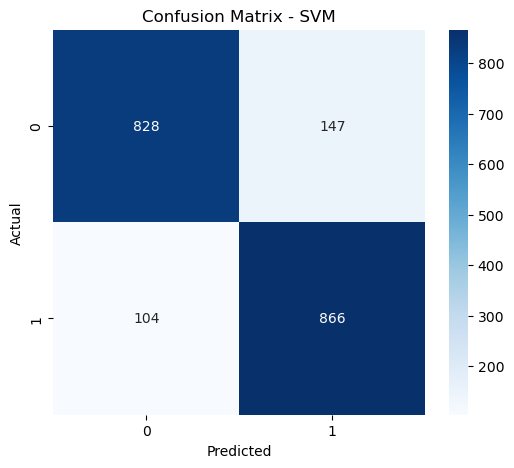

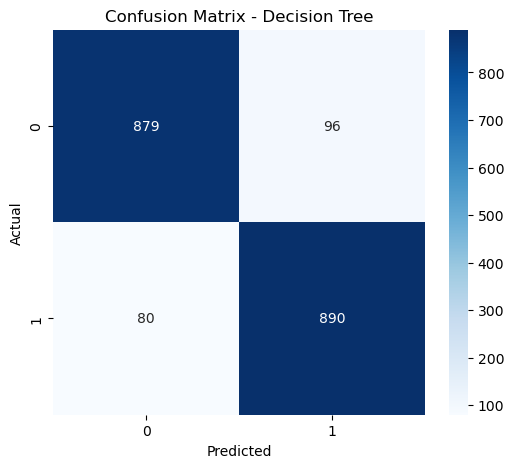

In [ ]:
# Confusion Matrices

# Create confusion matrix comparing between validation data and prediced (Logistic Regression)
cm_LogReg = confusion_matrix(y_valid, y_pred_LogReg)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_LogReg, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Create confusion matrix comparing between validation data and prediced (SVM)
cm_SVM = confusion_matrix(y_valid, y_pred_SVM)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_SVM, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

# Create confusion matrix comparing between validation data and prediced (Decision Tree)
cm_DT = confusion_matrix(y_valid, y_pred_clfDT)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_DT, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

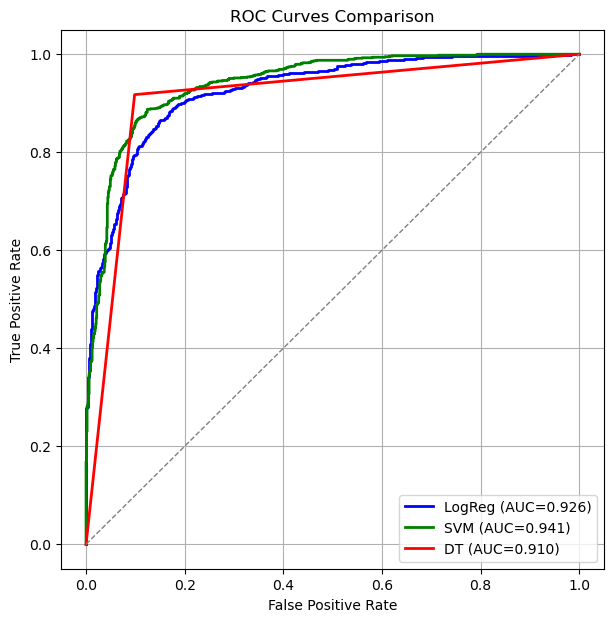

In [138]:
# ROC Curves
from sklearn.metrics import roc_curve, auc

# Logistic Regression
# Get probabilities for the positive class
y_pred_proba_LogReg = LogReg.predict_proba(X_valid)[:, 1]

# Compute ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_valid, y_pred_proba_LogReg)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# SVM
y_pred_proba_SVM = svm.predict_proba(X_valid)[:, 1]

# Compute ROC
fpr_svm, tpr_svm, _ = roc_curve(y_valid, y_pred_proba_SVM)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Decision Tree
y_pred_proba_DT = clfDT.predict_proba(X_valid)[:, 1]

# Compute ROC
fpr_dt, tpr_dt, _ = roc_curve(y_valid, y_pred_proba_DT)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(7,7))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'LogReg (AUC={roc_auc_lr:.3f})')
plt.plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'SVM (AUC={roc_auc_svm:.3f})')
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, label=f'DT (AUC={roc_auc_dt:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### Interpretation of Evaluation Metrics

All three models, Logistic Regression, SVM, and Decision Tree, perform well in identifying patients at risk of having a stroke. The differences between the models show the differing implications of these models for developing predictive models in a health care context. Overall, the performance of the logistic regression model was very good, with equal measures of precision and recall and an F1 score of 0.859. The ability of this model to correctly predict stroke cases and limit false positives provides a good foundation for predictive modeling. The high recall (0.885) of the logistic regression model is especially valuable when it comes to screening for health risks, since failing to identify a person who has a high risk of developing a serious condition like stroke could have serious consequences. The high precision (0.85) of the model means that most people identified by the model as being at high risk actually do have a high risk, which will reduce the number of times they need to follow up with their physician.

The SVM model performed slightly better than the logistic regression model. The best performance of the SVM model was in its recall (0.893), and its F1 score (0.873). The improved performance of the SVM model in identifying stroke-positive cases, while keeping the false positives low, provides additional advantages for a risk detection problem. Because the SVM uses margin-based decision boundaries, it is able to find more complex relationships between patient characteristics than the logistic regression model, which finds only linear relationships.

The Decision Tree model had the highest evaluation metrics, with an accuracy of .91 and an F1 score of 0.91. The high accuracy and high F1 score of the Decision Tree model indicates that it is the most accurate of the three models in differentiating between stroke and non-stroke cases. The combination of high precision (0.903) and high recall (0.918) of the Decision Tree model means that it identifies almost all stroke cases and incorrectly predicts a stroke case fewer times than either of the other two models. While Decision Trees have the disadvantage of possibly over fitting the data, it could be a good candidate for further validation and potentially use in a real world clinical risk prediction setting.

## Hyperparameter Tuning

In [123]:
# Logistic Regression parameter grids
grid_liblinear = {
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [500, 1000, 2000]
}

grid_lbfgs = {
    'solver': ['lbfgs'],
    'penalty': ['l2', None],
    'C': [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [500, 1000, 2000]
}

grid_saga_elastic = {
    'solver': ['saga'],
    'penalty': ['elasticnet'],
    'l1_ratio': [0.2, 0.5, 0.8],
    'C': [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [500, 1000, 2000]
}

grid_saga_l1_l2 = {
    'solver': ['saga'],
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [500, 1000, 2000]
}

param_grid_lr = [grid_liblinear, grid_saga_elastic, grid_saga_l1_l2, grid_lbfgs]

# SVM parameter grid
param_grid_svm = {
    'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 20],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4]
}

# Decision Tree parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, 30, 35, 40, 45, 50],
    'min_samples_split': [2, 5, 6, 8, 10, 20, 40, 60, 80, 100],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10, 12, 14, 16],
    'min_impurity_decrease': [0, 0.0005, 0.001, 0.005, 0.01, 0.03, 0.05, 0.07, 0.1],
    'criterion': ['gini', 'entropy', 'log_loss']
}


In [124]:
# 1) Logistic Regression pipeline

# Search for best params (Logistic Regression)
LogReg_gridSearch = GridSearchCV(LogisticRegression(), param_grid=param_grid_lr, cv=5, n_jobs=-1, verbose=1, scoring='f1')
LogReg_gridSearch.fit(X_train, y_train)
print('Logistic Regression')
print('F1 Score: ', LogReg_gridSearch.best_score_)
print('Best Parameters: ', LogReg_gridSearch.best_params_)

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Logistic Regression
F1 Score:  0.8497217707899949
Best Parameters:  {'C': 0.1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}


In [128]:
# Search for best params (SVM)
SVM_gridSearch = GridSearchCV(SVC(), param_grid=param_grid_svm, cv=5, n_jobs=-1, verbose=1, scoring='f1')
SVM_gridSearch.fit(X_train, y_train)
print('SVM')
print('F1 Score: ', SVM_gridSearch.best_score_)
print('Best Parameters: ', SVM_gridSearch.best_params_)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
SVM
F1 Score:  0.8846352717110854
Best Parameters:  {'C': 20, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [122]:
# Search for best params (Decision Tree)
DT_gridSearch = GridSearchCV(DecisionTreeClassifier(), param_grid=param_grid_dt, cv=5, n_jobs=-1, verbose=1, scoring='f1')
DT_gridSearch.fit(X_train, y_train)
print('Decision Tree')
print('F1 Score: ', DT_gridSearch.best_score_)
print('Best Parameters: ', DT_gridSearch.best_params_)

Fitting 5 folds for each of 21870 candidates, totalling 109350 fits
Decision Tree
F1 Score:  0.9096043785980699
Best Parameters:  {'criterion': 'log_loss', 'max_depth': 30, 'min_impurity_decrease': 0, 'min_samples_leaf': 1, 'min_samples_split': 2}


Hyperparameter Tuning Justification:

My hyperparameter tuning strategies stemmed from the class examples we have went through. Tuning began by going to SkLearn documentation to get a list of potential hyperparameters and filled in values in a range and kept rerunning the GridSearchCV until I was satisfied with my tuning results. A similar process is detailed in Data Mining for Business Analytics Chapter 9.3. 

### Model Evaluation After Hyperparameter Tuning

#### Logistic Regression (Tuned)

In [134]:
# Load in the best estimator for Logistic Regression from the GridSearch CV
LogReg_tuned = LogReg_gridSearch.best_estimator_

# Predict
y_pred_LogReg_tuned = LogReg_tuned.predict(X_valid)

# Calculate the accuracy score
accuracy_LogReg_tuned = accuracy_score(y_valid, y_pred_LogReg_tuned)

# Calculate the precision
precision_LogReg_tuned = precision_score(y_valid, y_pred_LogReg_tuned)

# Calculate the recall
recall_LogReg_tuned = recall_score(y_valid, y_pred_LogReg_tuned)

# Calculate the F1 Score
f1_LogReg_tuned = f1_score(y_valid, y_pred_LogReg_tuned)

print("Logistic Regression (Tuned) Metrics")
print(f"Accuracy: {accuracy_LogReg_tuned:.3f}")
print(f"Precision: {precision_LogReg_tuned:.3f}")
print(f"Recall: {recall_LogReg_tuned:.3f}")
print(f"F1 Score: {f1_LogReg_tuned:.3f}")

Logistic Regression (Tuned) Metrics
Accuracy: 0.857
Precision: 0.833
Recall: 0.891
F1 Score: 0.861


#### SVM (Tuned)

In [133]:
#SVM Model
SVM_tuned = SVM_gridSearch.best_estimator_

# Predict
y_pred_SVM_tuned = SVM_tuned.predict(X_valid)

# Calculate the accuracy score
accuracy_SVM_tuned = accuracy_score(y_valid, y_pred_SVM_tuned)

# Calculate the precision
precision_SVM_tuned = precision_score(y_valid, y_pred_SVM_tuned)

# Calculate the recall
recall_SVM_tuned = recall_score(y_valid, y_pred_SVM_tuned)

# Calculate the F1 Score
f1_SVM_tuned = f1_score(y_valid, y_pred_SVM_tuned)

print("SVM (Tuned) Metrics")
print(f"Accuracy: {accuracy_SVM_tuned:.3f}")
print(f"Precision: {precision_SVM_tuned:.3f}")
print(f"Recall: {recall_SVM_tuned:.3f}")
print(f"F1 Score: {f1_SVM_tuned:.3f}")

SVM (Tuned) Metrics
Accuracy: 0.887
Precision: 0.859
Recall: 0.927
F1 Score: 0.891


#### Decision Tree (Tuned)

In [132]:
# Fit a decision tree classifier with default hyperparameters called clfDT to the training dataset
clfDT_tuned = DT_gridSearch.best_estimator_

# Predict
y_pred_clfDT_tuned = clfDT_tuned.predict(X_valid)

# Calculate the accuracy score
accuracy_clfDT_tuned = accuracy_score(y_valid, y_pred_clfDT_tuned)

# Calculate the precision
precision_clfDT_tuned = precision_score(y_valid, y_pred_clfDT_tuned)

# Calculate the recall
recall_clfDT_tuned = recall_score(y_valid, y_pred_clfDT_tuned)

# Calculate the F1 Score
f1_clfDT_tuned = f1_score(y_valid, y_pred_clfDT_tuned)

print("Decision Tree (Tuned) Metrics")
print(f"Accuracy: {accuracy_clfDT_tuned:.3f}")
print(f"Precision: {precision_clfDT_tuned:.3f}")
print(f"Recall: {recall_clfDT_tuned:.3f}")
print(f"F1 Score: {f1_clfDT_tuned:.3f}")

Decision Tree (Tuned) Metrics
Accuracy: 0.914
Precision: 0.908
Recall: 0.922
F1 Score: 0.915


## Model Comparison and Selection

### Side by Side Comparison

| Model                   | Accuracy | Precision | Recall | F1 Score |
|-------------------------|----------|-----------|--------|----------|
| Logistic Regression     | 0.857    | 0.833     | 0.891  | 0.861    |
| SVM                     | 0.887    | 0.859     | 0.927  | 0.891    |
| Decision Tree           | 0.914    | 0.908     | 0.922  | 0.915    |


### Best Model and Why

The Decision Tree model has the best results overall, as it produces the best accuracy (.914) and F1 scores (.915) which indicate good consistency and fairness of classification results of both positive and negative stroke-risk classifications. The Decision Tree model is able to better detect non-linear interaction effects among health characteristics than the linear Logistic Regression model and slightly out performs the SVM model in terms of precision, with a similar level of recall to the SVM model. A high degree of precision, or few false alarms, and a high degree of sensitivity, or few false negatives, will make the model useful for early screening purposes where there are serious consequences associated with either missing detection or producing too many false alarms.

Decision Trees offer additional value beyond just their predictive strength. The SVM model offers strong predictive power, but offers less interpretability of the predictive process than the Decision Tree model. Decision Trees offer a clear, understandable structure to healthcare professionals split by split and therefore support ethically responsible model use, as patients and providers, should be able to question the predictive process of any model that is used to guide decisions that impact patient care. Logistic Regression offers some interpretation capabilities, but limits itself through its assumption of linearity in the relationship between stroke risk factors.

There are trade-offs to consider here. If not properly tuned, Decision Trees can fit the training data too closely and become overly sensitive to small variations in the data. Also, even when well-tuned, the boundary between high and low stroke-risk will vary based upon the specific values of the input variables. SVM models are very powerful, but lack transparency and therefore cannot be inspected or questioned in the same way as Decision Trees. Lastly, Logistic Regression models may perform poorly in cases where the relationship between the predictor variables and the outcome variable includes important feature interactions. With all the above trade-offs and benefits in mind, the Decision Tree model appears to offer the best overall combination of performance, interpretability and practical responsibility in this case.

Important Note:

While researching studies for the best way to tackle the imbalance in the stroke class there were three papers that took to using SMOTE on the entire dataset. I took this as best practice and applied a similar technique to this project. After doing some reading in the Data Mining for Business Analytics book, Chapter 5.5 highlights that best practice would be to just oversample the training data to keep synthetic data out of the validation dataset because this would allow evaluations to be more robust to what would be seen in the real-world. This makes me question the validity of the 3 studies that were read because by using SMOTE on the entire dataset it appears to make the results more believable for real-world use than they really may be.

Studies:

S. Gupta and S. Raheja, “Stroke Prediction using Machine Learning Methods,” IEEE Xplore, Jan. 01, 2022. https://ieeexplore.ieee.org/document/9734197.

J. Rodriguez "Stroke prediction through Data Science and Machine Learning Algorithms" https://www.researchgate.net/profile/Jose_A_Tavares/publication/352261064_Stroke_prediction_through_Data_Science_and_Machine_Learning_Algorithms/links/60c1071f92851ca6f8d6100b/Stroke-prediction-through-Data-Science-and-Machine-Learning-Algorithms.pdf

T. Tazin, M. N. Alam, N. N. Dola, M. S. Bari, S. Bourouis, and M. Monirujjaman Khan, “Stroke Disease Detection and Prediction Using Robust Learning Approaches,” Journal of Healthcare Engineering, vol. 2021, p. e7633381, Nov. 2021, doi: https://doi.org/10.1155/2021/7633381.
